In [2]:
# imports
import datetime
import time

import matplotlib.pyplot as plt
import numpy as np
import pyodbc
import pandas as pd
from pandas import DataFrame
from pyodbc import Row

In [ ]:
def time_to_seconds(_time: datetime.time) -> int:
    """
    params:
    _time in [00:00:00, 23:59:59]

    returns: 
    out in [0, 86399]
    """
    return _time.hour * 3600 + _time.minute * 60 + _time.second

def seconds_to_time(total_seconds: int) -> datetime.time:
    """
    params:
    total_seconds in [0, 86399]

    returns:
    out in [00:00:00, 23:59:59]
    """
    if not (0 <= total_seconds < 86399):
        raise ValueError

    hour = total_seconds // 3600
    remaining_seconds = total_seconds % 3600

    minute = remaining_seconds // 60
    second = remaining_seconds % 60

    return datetime.time(hour=hour, minute=minute, second=second)

def format_time_to_ms(_time: float) -> str:
    return f"{_time * 1000:.2f}ms"

83646
23:14:06


In [4]:
# configs
name_map: dict[str, str] = {
    "dow": "day_of_week",
    "dom": "day_of_month",
    "doy": "day_of_year",
    "wn": "week_number",
    "mn": "month_number",
    "qn": "quarter_number",
    "yn": "year_number",
}


def sql_grain_pt(grain: str) -> str:
    return f"""
    SELECT
        o.{grain},
        CONVERT(TIME, o.order_purchase_timestamp) AS purchase_time,
        DATEDIFF(SECOND, o.order_purchase_timestamp, order_approved_at)
            AS diff_purchase_to_approve_s
    FROM sales.vw_orders_practical AS o
    ORDER BY
        o.{grain},
        purchase_time,
        diff_purchase_to_approve_s
    """

sql_pt_day = """
    SELECT
        CONVERT(TIME, o.order_purchase_timestamp) AS purchase_time
    FROM sales.vw_orders_practical AS o
    ORDER BY purchase_time;
"""

# connect
driver = "ODBC Driver 17 for SQL Server"
server = "localhost"
database = "olist"

connstring: str = f"""
    DRIVER={{{driver}}};
    SERVER={server};
    DATABASE={database};
    Trusted_Connection=yes;
"""
tik_connect = time.perf_counter()
conn = pyodbc.connect(connstring, timeout=60)
cursor = conn.cursor()
tok_connect = time.perf_counter()

# get day table
day_pt_rows: list[Row] = cursor.execute(sql_pt_day).fetchall()

day_pt_columns: list[str] = [description[0] for description in cursor.description]
df_pt_day: DataFrame = pd.DataFrame(
    (tuple(r) for r in day_pt_rows), columns=day_pt_columns
)

# get other tables
dfs_pt: dict[str, DataFrame] = {}

for name in name_map:
    df_name = f"{name}"
    grain = name_map[name]

    sql = sql_grain_pt(grain=grain)
    grain_pt_rows: list[Row] = cursor.execute(sql).fetchall()

    grain_pt_columns: list[str] = [description[0] for description in cursor.description]
    df_grain_pt = pd.DataFrame(
        (tuple(r) for r in grain_pt_rows), columns=grain_pt_columns
    )

    dfs_pt[df_name] = df_grain_pt

conn.close()

print(f"Connect to DB: {format_time_to_ms(tok_connect - tik_connect)}")

Connect to DB: 72.78ms


In [14]:
# clean
time_to_seconds_column_name = "purchase_time_s"

tik_day = time.perf_counter()
if not df_pt_day.columns.str.contains(time_to_seconds_column_name).any():
    df_pt_day[time_to_seconds_column_name] = df_pt_day["purchase_time"].apply(
        time_to_seconds
    )
tok_day = time.perf_counter()

tik_other = time.perf_counter()
for i in dfs_pt:
    if not dfs_pt[i].columns.str.contains(time_to_seconds_column_name).any():
        dfs_pt[i][time_to_seconds_column_name] = dfs_pt[i]["purchase_time"].apply(
            time_to_seconds
        )
tok_other = time.perf_counter()

print(f"Clean `df_pt_day`: {format_time_to_ms(tok_day - tik_day)}")
print(f"Clean `dfs_pt`: {format_time_to_ms(tok_other - tik_other)}")

Clean `df_pt_day`: 0.56ms
Clean `dfs_pt`: 1.15ms


In [15]:
bin_map = {
    '10m': 6*24,
    '15m': 4*24,
    '30m': 2*24,
    '1h': 24
}

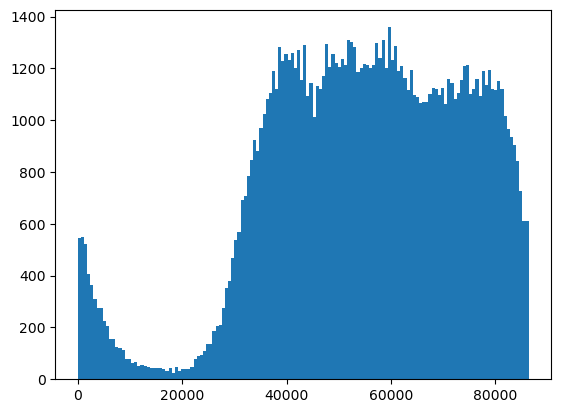

In [16]:
fig, ax = plt.subplots()

ax.hist(df_pt_day['purchase_time_s'], bins=bin_map['10m'])
plt.show()

In [28]:
dfs_pt['dow']

,day_of_week,purchase_time,diff_purchase_to_approve_s,purchase_time_s
0,1,00:00:01,914.0,1
1,1,00:00:01,1526.0,1
2,1,00:00:13,88497.0,13
3,1,00:00:13,88497.0,13
4,1,00:00:29,1120.0,29
...,...,...,...,...
112171,7,23:59:42,0.0,86382
112172,7,23:59:44,182061.0,86384
112173,7,23:59:45,6324.0,86385
112174,7,23:59:54,926.0,86394
